# Chapter 3: Rule-Based Classifiers - Combined Exercises and Solutions

This notebook contains practice exercises (~90 minutes).
Each exercise has a code cell for students and a *Solution Hint* section with code.
Tip: You can collapse the solution cells in Jupyter Notebook/Lab to hide them during class.

Nguyen Phuc Minh Chau - 22302421

## Setup Library

### Install Library

In [ ]:
# Wittgenstein
!pip install wittgenstein

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.6/110.6 kB 3.0 MB/s eta 0:00:00


### Import Library

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import wittgenstein as lw

## Exercise 1: Sequetial Covering

### Exercise 1: Load the Iris dataset and determine the rule set using algorithm Sequential Covering Algorithm

In [ ]:
# 1. Load Iris Dataset
iris = load_iris(as_frame=True)
df = iris.data
df['class'] = iris.target
df['class'] = df['class'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# 2. Detemine Rule Accuracy
def rule_accuracy(rule, data, target_class):
  convered = data.query(rule)
  if len(convered) == 0:
    return 0, 0
  acc = (convered['class'] == target_class).mean()
  return acc, len(convered)

# 3. Learn-One-Rule
def learn_one_rule(data, target_class, min_acc=0.9, min_cov=5):
    best_rule, best_acc, best_cov = None, 0, 0
    for col in data.columns[:-1]:
        for t in np.unique(data[col]):
            for op in ["<=", ">="]:
                rule = f"`{col}` {op} {t}"
                acc, cov = rule_accuracy(rule, data, target_class)
                if acc >= min_acc and cov >= min_cov and acc > best_acc:
                    best_rule, best_acc, best_cov = rule, acc, cov
    return best_rule, best_acc, best_cov

# 4. Sequential Covering
def sequential_covering(data, target_class, min_acc=0.9, min_cov=5):
    rules = []
    remaining = data.copy()
    while True:
        rule, acc, cov = learn_one_rule(remaining, target_class, min_acc, min_cov)
        if rule is None:
            break
        rules.append((rule, target_class, acc, cov))
        covered = remaining.query(rule).index
        remaining = remaining.drop(covered)
        if remaining.empty:
            break
    return rules

# 5. Setting Rule For All Class
all_rules = []
for c in df["class"].unique():
    rules = sequential_covering(df, c, min_acc=0.9, min_cov=5)
    all_rules.extend(rules)

print("=== Rule Learned ===")
for rule, cls, acc, cov in all_rules:
    print(f"IF {rule} THEN class = {cls} (acc={acc:.2f}, covered={cov})")

=== Rule Learned ===
IF `sepal length (cm)` <= 4.5 THEN class = setosa (acc=1.00, covered=5)
IF `sepal length (cm)` <= 4.7 THEN class = setosa (acc=1.00, covered=6)
IF `sepal length (cm)` <= 4.8 THEN class = setosa (acc=1.00, covered=5)
IF `sepal width (cm)` >= 3.9 THEN class = setosa (acc=1.00, covered=6)
IF `petal length (cm)` <= 1.4 THEN class = setosa (acc=1.00, covered=10)
IF `petal length (cm)` <= 1.5 THEN class = setosa (acc=1.00, covered=10)
IF `petal length (cm)` <= 1.7 THEN class = setosa (acc=1.00, covered=7)
IF `sepal length (cm)` >= 7.1 THEN class = virginica (acc=1.00, covered=12)
IF `petal length (cm)` >= 5.2 THEN class = virginica (acc=1.00, covered=22)
IF `petal width (cm)` >= 1.9 THEN class = virginica (acc=1.00, covered=8)


### Exercise 2: Perform classification and print the accuracy of the classification model

In [ ]:
# Predict
def predict_one(row, rules, default_class="setosa"):
    for rule, cls, _, _ in rules:
        if row.to_frame().T.query(rule).shape[0] > 0:
            return cls
    return default_class

def predict(df, rules):
    preds = []
    majority_class = df["class"].mode().iloc[0]
    for _, row in df.drop(columns="class").iterrows():
        preds.append(predict_one(row, rules, default_class=majority_class))
    return preds

y_true = df["class"].tolist()
y_pred = predict(df, all_rules)
acc = accuracy_score(y_true, y_pred)
print("\n=== Accuracy Entire Iris Dataset ===")
print(f"Accuracy = {acc:.3f}")


=== Accuracy Entire Iris Dataset ===
Accuracy = 0.613


### Exercise 3: Visualization to compare True Label and Predicted Label

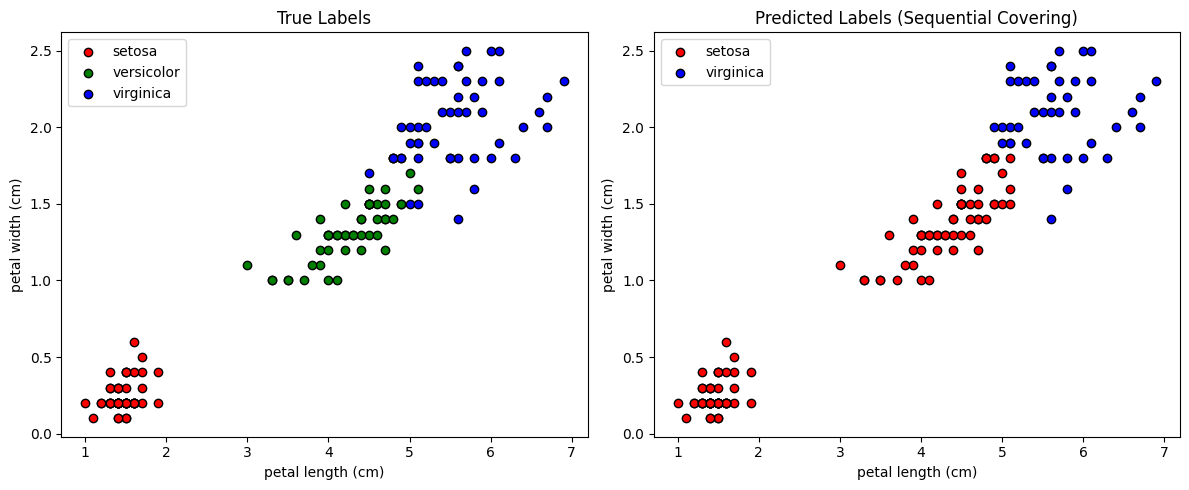

In [ ]:
df["predicted"] = y_pred
color_map = {"setosa":"red", "versicolor":"green", "virginica":"blue"}
plt.figure(figsize=(12,5))

# True labels
plt.subplot(1,2,1)
for cname, grp in df.groupby("class"):
    plt.scatter(grp["petal length (cm)"], grp["petal width (cm)"],
                label=cname, color=color_map[cname], edgecolor="k")
plt.title("True Labels")
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.legend()

# Predicted labels
plt.subplot(1,2,2)
for pname, grp in df.groupby("predicted"):
    plt.scatter(grp["petal length (cm)"], grp["petal width (cm)"],
                label=pname, color=color_map[pname], edgecolor="k")
plt.title("Predicted Labels (Sequential Covering)")
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.legend()

plt.tight_layout()
plt.show()

### Exercise 4: Show the Confusion Maxtrix & the Classification Report

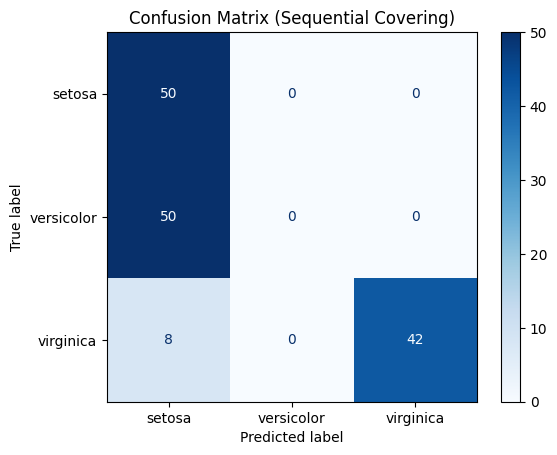


=== Classification Report ===
              precision    recall  f1-score   support

      setosa       0.46      1.00      0.63        50
  versicolor       0.00      0.00      0.00        50
   virginica       1.00      0.84      0.91        50

    accuracy                           0.61       150
   macro avg       0.49      0.61      0.52       150
weighted avg       0.49      0.61      0.52       150



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# 9. Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=["setosa","versicolor","virginica"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["setosa","versicolor","virginica"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Sequential Covering)")
plt.show()

# 10. Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=["setosa","versicolor","virginica"]))

## Excercise 2: RIPPER OVR (One-VS-Reset)

### Exercise 1: Load the Iris dataset

In [ ]:
iris = load_iris(as_frame=True)
df = iris.data
df["class"] = iris.target
df["class"] = df["class"].map({0:"setosa", 1:"versicolor", 2:"virginica"})

X = df.drop(columns="class")
y = df["class"]

### Exercise 2: RIPPER Training One-vs-Rest

In [ ]:
models = {}
for cls in y.unique():
    y_binary = (y == cls).astype(int)
    ripper = lw.RIPPER()
    ripper.fit(X, y_binary, pos_class=1)
    models[cls] = ripper
    print(f"=== Rule For Class {cls} ===")
    print(ripper.ruleset_)
    print()

=== Rule For Class setosa ===
[[petalwidth(cm)=<0.2] V [petalwidth(cm)=0.2-0.4] V [petallength(cm)=1.5-1.7]]

=== Rule For Class versicolor ===
[[petalwidth(cm)=1.16-1.3] V [petalwidth(cm)=1.3-1.5^petallength(cm)=4.35-4.64] V [petalwidth(cm)=0.4-1.16] V [petallength(cm)=4.64-5.0^sepallength(cm)=6.52-6.9] V [petalwidth(cm)=1.3-1.5] V [sepalwidth(cm)=3.2-3.4^petalwidth(cm)=1.5-1.8]]

=== Rule For Class virginica ===
[[petallength(cm)=5.32-5.8] V [petallength(cm)=>5.8] V [petallength(cm)=5.0-5.32] V [petallength(cm)=4.64-5.0^petalwidth(cm)=1.9-2.2] V [petalwidth(cm)=1.5-1.8]]



### Exercise 3: Predict by choosing the class with the highest confidence

In [ ]:
def predict_ovr(X, models):
    preds = []
    for _, row in X.iterrows():
        scores = {}
        for cls, model in models.items():
            prob = model.predict_proba([row])[0][1]
            scores[cls] = prob

        pred_class = max(scores, key=scores.get)
        preds.append(pred_class)

    return preds
    y_pred = predict_ovr(X, models)

### Exercise 4: Show accuracy of the classification model

In [ ]:
y_true = y.tolist()
acc = accuracy_score(y_true, y_pred)
print("\n=== Độ chính xác trên toàn bộ Iris dataset ===")
print(f"Accuracy = {acc:.3f}")


=== Độ chính xác trên toàn bộ Iris dataset ===
Accuracy = 0.973


### Exercise 5: Visualization to compare True Label and Predicted Label

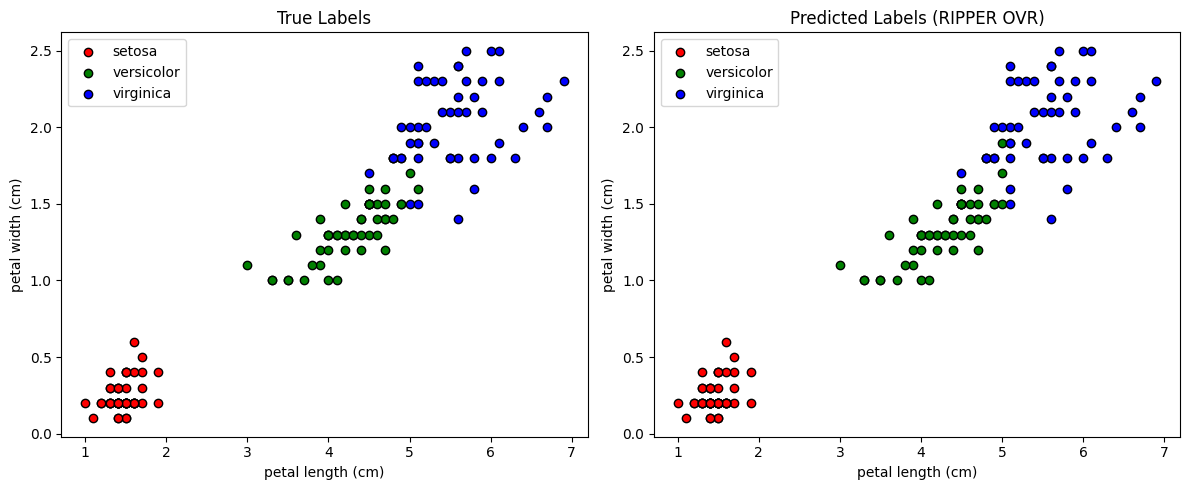

In [ ]:
df["predicted"] = y_pred

color_map = {"setosa":"red", "versicolor":"green", "virginica":"blue"}

plt.figure(figsize=(12,5))

# True labels
plt.subplot(1,2,1)
for cname, grp in df.groupby("class"):
    plt.scatter(grp["petal length (cm)"], grp["petal width (cm)"],
                label=cname, color=color_map[cname], edgecolor="k")
plt.title("True Labels")
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.legend()

# Predicted labels
plt.subplot(1,2,2)
for pname, grp in df.groupby("predicted"):
    plt.scatter(grp["petal length (cm)"], grp["petal width (cm)"],
                label=pname, color=color_map[pname], edgecolor="k")
plt.title("Predicted Labels (RIPPER OVR)")
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.legend()

plt.tight_layout()
plt.show()

### Exercise 6: Show the Confusion Maxtrix & the Classification Report

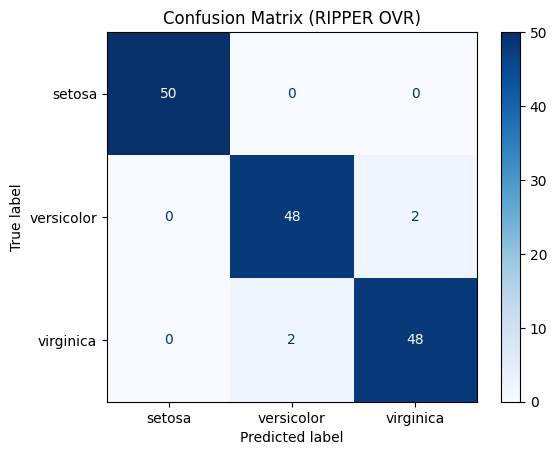


=== Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.96      0.96      0.96        50
   virginica       0.96      0.96      0.96        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=["setosa","versicolor","virginica"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["setosa","versicolor","virginica"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (RIPPER OVR)")
plt.show()

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=["setosa","versicolor","virginica"]))

## Exercise 3:

### Exercise 1: Execute the following code to classify Iris flowers using RIPPER algorithm

=== Luật cho class setosa ===
[[petalwidth(cm)=<0.2] V [petalwidth(cm)=0.2-0.4] V [petallength(cm)=1.5-1.7]]

=== Luật cho class versicolor ===
[[petalwidth(cm)=1.16-1.3] V [petalwidth(cm)=1.3-1.5^sepalwidth(cm)=2.8-3.0] V [petalwidth(cm)=1.3-1.5^sepallength(cm)=6.52-6.9] V [petalwidth(cm)=0.4-1.16^petallength(cm)=1.7-3.9] V [petallength(cm)=4.64-5.0^sepalwidth(cm)=3.1-3.2] V [petallength(cm)=4.35-4.64] V [petallength(cm)=3.9-4.35] V [petallength(cm)=4.64-5.0^sepallength(cm)=6.52-6.9]]

=== Luật cho class virginica ===
[[petallength(cm)=5.32-5.8] V [petallength(cm)=>5.8] V [petallength(cm)=5.0-5.32] V [petallength(cm)=4.64-5.0^sepalwidth(cm)=<2.5] V [petalwidth(cm)=1.9-2.2] V [petalwidth(cm)=1.5-1.8^sepallength(cm)=4.8-5.0]]


=== Độ chính xác trên toàn bộ Iris dataset ===
Accuracy = 0.967


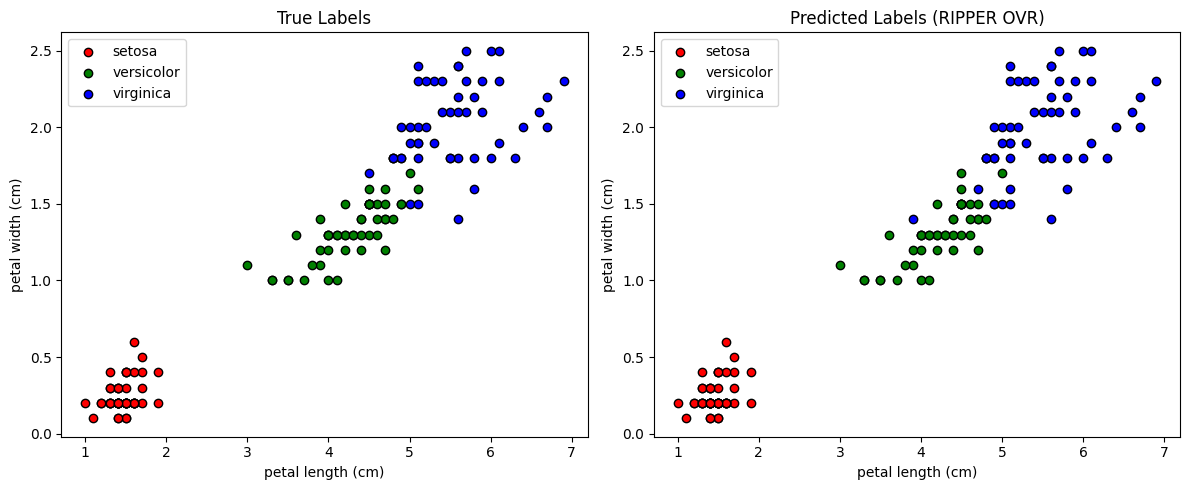

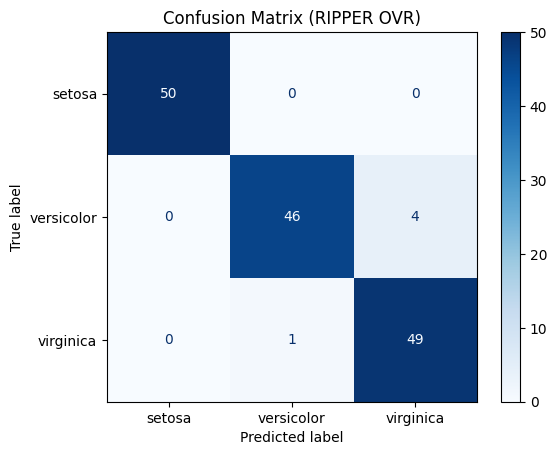


=== Classification Report ===
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.98      0.92      0.95        50
   virginica       0.92      0.98      0.95        50

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150



In [33]:
# 1. Load dataset
iris = load_iris(as_frame=True)
df = iris.data
df["class"] = iris.target
df["class"] = df["class"].map({0:"setosa", 1:"versicolor", 2:"virginica"})

X = df.drop(columns="class")
y = df["class"]

# 2. Huấn luyện RIPPER theo One-vs-Rest (OVR)
models = {}
for cls in y.unique():
    # chuyển True → 1, False → 0 → thành nhãn nhị phân [1, 0]
    y_binary = (y == cls).astype(int)  # one-vs-rest
    ripper = lw.RIPPER()
    ripper.fit(X, y_binary, pos_class=1)
    models[cls] = ripper
    print(f"=== Luật cho class {cls} ===")
    print(ripper.ruleset_)
    print()

# 3. Dự đoán bằng cách chọn class có độ tin cậy (confidence) cao nhất
def predict_ovr(X, models):
    """
    Hàm dự đoán nhãn cho dữ liệu X bằng phương pháp One-vs-Rest (OVR).

    Ý tưởng:
    - Mỗi class có một mô hình RIPPER riêng (huấn luyện nhị phân: class đó = 1, còn lại = 0).
    - Với mỗi mẫu dữ liệu (row):
        + Ta lấy xác suất dự đoán "p(y=1)" từ mô hình của từng class.
        + Tập hợp các xác suất này thành một dictionary scores: {class: xác suất}.
        + Chọn class có xác suất (confidence) cao nhất làm nhãn dự đoán cuối cùng.
    - Cách này gọi là "Dự đoán bằng cách chọn lớp có độ tin cậy cao nhất".
    """

    preds = []
    for _, row in X.iterrows():
        scores = {}
        for cls, model in models.items():
            # predict_proba([row]) trả về [p(y=0), p(y=1)]
            # Ta lấy phần tử [1] = xác suất mẫu thuộc class này (positive class)
            prob = model.predict_proba([row])[0][1]
            scores[cls] = prob

        # Lấy class có xác suất cao nhất
        pred_class = max(scores, key=scores.get)
        preds.append(pred_class)

    return preds

y_pred = predict_ovr(X, models)

# 4. Đánh giá
y_true = y.tolist()
acc = accuracy_score(y_true, y_pred)
print("\n=== Độ chính xác trên toàn bộ Iris dataset ===")
print(f"Accuracy = {acc:.3f}")

# 5. Thêm nhãn dự đoán vào dataframe
df["predicted"] = y_pred

# 6. Trực quan hóa true vs predicted
color_map = {"setosa":"red", "versicolor":"green", "virginica":"blue"}

plt.figure(figsize=(12,5))

# True labels
plt.subplot(1,2,1)
for cname, grp in df.groupby("class"):
    plt.scatter(grp["petal length (cm)"], grp["petal width (cm)"],
                label=cname, color=color_map[cname], edgecolor="k")
plt.title("True Labels")
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.legend()

# Predicted labels
plt.subplot(1,2,2)
for pname, grp in df.groupby("predicted"):
    plt.scatter(grp["petal length (cm)"], grp["petal width (cm)"],
                label=pname, color=color_map[pname], edgecolor="k")
plt.title("Predicted Labels (RIPPER OVR)")
plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.legend()

plt.tight_layout()
plt.show()

# 7. Confusion Matrix
cm = confusion_matrix(y_true, y_pred, labels=["setosa","versicolor","virginica"])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=["setosa","versicolor","virginica"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (RIPPER OVR)")
plt.show()

# 8. Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_true, y_pred, target_names=["setosa","versicolor","virginica"]))

### Exercise 2: Explain the confusion matrix

**Your answer:**

Confusion Matrix của Thuật toán RIPPER OVR (One-VS-Reset) dựa trên 2 bảng True và Predicted.

Nhận thấy với mỗi class có 50 tập dữ liệu:
- setosa thuật toán xác định đúng 50/50
- versicolor thuật toán xác định đúng 46/50, 4/50 sai với nhãn virginica
- virginica thuật toán xác định đúng 49/50, 1/50 sai với nhãn versicolor

### Exercise 3: Explain the Classification Report

**Your answer:**

Classìication Report phản ánh:
- Chi tiết từng lớp:
  + Setosa:
    + Precision là 1, tức dự đoán chính xác class là 100% (50/50)
    + Recall là 1, tức nhận ra chính xác class là 100% (50/50)
    + F1 Score là 1, tức tổng quát chính xác là 100% (50/50)
  + Versicolor:
    + Precision là 0.98, tức dự đoán chính xác class là 98% (49/50)
    + Recall là 0.92, tức nhận ra chính xác class là 92% (46/50)
    + F1 Score là 0.95, tức tổng quát chính xác là 95% (47-48/50)
  + Virginica:
    + Precision là 0.92, tức dự đoán chính xác class là 92% (46/50)
    + Recall là 0.98, tức nhận ra chính xác class là 98% (49/50)
    + F1 Score là 0.95, tức tổng quát chính xác là 95% (47-48/50)

- Tổng thể:
  + Accuracy tổng thể là 0.97, tức mô hình chính xác 97% (145/150)
  + Macro Average (Trung bình tổng quan):
    + Precision là 0.97, tức dự đoán chính xác class là 97%
    + Recall là 0.97, tức nhận ra chính xác class là 97%
    + F1 Score là 0.97, tức tổng quát chính xác là 97%
  + Weighted Average (Trung bình trọng số):
    + Precision là 0.97, tức dự đoán chính xác class là 97%
    + Recall là 0.97, tức nhận ra chính xác class là 97%
    + F1 Score là 0.97, tức tổng quát chính xác là 97%